# nb21 — Econ Neo-Colonial Score: Variance Audit

**Purpose:** Assess whether `econ_neocol_score_total` has sufficient discriminating power to detect the structural violence pathway, or whether the null result in nb16/nb17 reflects measurement failure rather than genuine absence of effect.

**Audit questions:**
1. Does raw ECI cluster at the low end for Global South countries?
2. How many dyads are zeroed out by the `.clip(0)` operation?
3. Does the score vary meaningfully within the Global South after clipping?
4. Is there any bivariate relationship between score and journalist killings once Global North senders are excluded?
5. Does the aggregated monadic score (`econ_neocol_score_total`) have enough variance to detect panel effects?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# project palette
RED    = '#BF3A27'
GOLD   = '#C7922A'
DARK   = '#323232'
GREY   = '#AAAAAA'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.edgecolor': DARK,
    'axes.labelcolor': DARK,
    'xtick.color': DARK,
    'ytick.color': DARK,
    'text.color': DARK,
})

In [2]:
# --- load raw ECI ---
eci_raw = pd.read_csv('../data/raw/economic/eci-rankings-raw.csv')
eci = eci_raw[['country_iso3_code', 'year', 'eci_hs92']].copy()
eci = eci.rename(columns={'country_iso3_code': 'iso3'})

print('ECI shape:', eci.shape)
print('Year range:', eci['year'].min(), '–', eci['year'].max())
print('Unique countries:', eci['iso3'].nunique())
print('Missingness:', eci['eci_hs92'].isnull().sum())
eci.head(3)

ECI shape: (4319, 3)
Year range: 1995 – 2024
Unique countries: 145
Missingness: 0


,iso3,year,eci_hs92
0,AFG,1995,-0.601
1,AFG,1996,-0.590
2,AFG,1997,-0.255


In [3]:
# --- load dyadic panel to get sender/receiver pairs and econ score ---
dyadic = pd.read_csv('../data/merged/dyadic_panel_1992_2024_oda_capped_log.csv')
print('Dyadic panel shape:', dyadic.shape)
print('Columns:', dyadic.columns.tolist())
dyadic.head(3)

Dyadic panel shape: (115640, 15)
Columns: ['sender_iso3', 'recipient_iso3', 'year', 'arms_tiv', 'bilateral_oda', 'econ_neocol_score', 'colonial_tie', 'journalist_killings', 'gdp_per_capita', 'gdp_per_capita_log', 'population', 'population_log', 'armed_conflict', 'conflict_intensity', 'econ_neocol_score_log']


,sender_iso3,recipient_iso3,year,arms_tiv,bilateral_oda,econ_neocol_score,colonial_tie,journalist_killings,gdp_per_capita,gdp_per_capita_log,population,population_log,armed_conflict,conflict_intensity,econ_neocol_score_log
0,ABW,ISR,1996,17.80,NaN,NaN,0,0,20224.278908,9.914639,5692000.0,15.554572,1.0,1.0,NaN
1,AGO,CIV,2002,1.72,NaN,0.000000e+00,0,0,967.815864,6.875042,18654771.0,16.741612,1.0,1.0,0.000000
2,ALB,BFA,2011,1.20,NaN,7.020872e-12,0,0,725.024768,6.586206,16661908.0,16.628636,0.0,0.0,0.006996


In [4]:
# --- load monadic panel for final score + outcome ---
panel = pd.read_csv('../data/merged/panel_final_1992_2024.csv')
print('Panel shape:', panel.shape)
panel[['recipient_iso3','year','econ_neocol_score_total','journalist_killings']].head(3)

Panel shape: (6358, 38)


,recipient_iso3,year,econ_neocol_score_total,journalist_killings
0,ABW,1992,0.0,0
1,ABW,1993,0.0,0
2,ABW,1994,0.0,0


## Section 1 — Raw ECI Distribution: Global North vs Global South

If ECI clusters tightly at the low end for Global South countries, the sender−receiver differential will have little variance to work with before the clip even fires.

Median ECI 2010: -0.002
group
High ECI (Global North proxy)    73
Low ECI (Global South proxy)     72
Name: count, dtype: int64


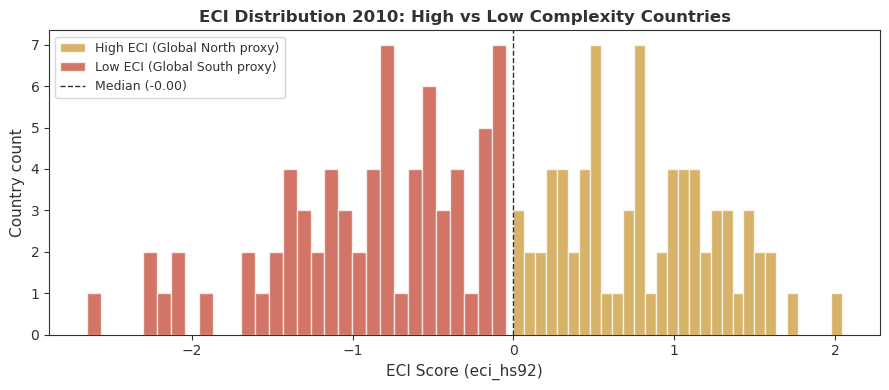

Saved.


In [5]:
# Define rough Global North / Global South split by ECI median
# Use 2010 as representative year
eci_2010 = eci[eci['year'] == 2010].copy()

median_eci = eci_2010['eci_hs92'].median()
eci_2010['group'] = np.where(eci_2010['eci_hs92'] >= median_eci, 'High ECI (Global North proxy)', 'Low ECI (Global South proxy)')

print(f'Median ECI 2010: {median_eci:.3f}')
print(eci_2010['group'].value_counts())

fig, ax = plt.subplots(figsize=(9, 4))

for grp, col in [('High ECI (Global North proxy)', GOLD), ('Low ECI (Global South proxy)', RED)]:
    vals = eci_2010.loc[eci_2010['group'] == grp, 'eci_hs92']
    ax.hist(vals, bins=30, alpha=0.7, color=col, label=grp, edgecolor='white')

ax.axvline(median_eci, color=DARK, linestyle='--', linewidth=1, label=f'Median ({median_eci:.2f})')
ax.set_xlabel('ECI Score (eci_hs92)', fontsize=11)
ax.set_ylabel('Country count', fontsize=11)
ax.set_title('ECI Distribution 2010: High vs Low Complexity Countries', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/final_report/04_appendix/fig_audit_eci_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## Section 2 — Clip Loss: How Many Dyads Are Zeroed Out?

The `.clip(0)` zeros out any dyad where `ECI_sender < ECI_receiver`. This is intentional (excludes Global North receivers) but may also zero out large portions of South-South trade.

In [6]:
# Check if dyadic panel has sender/receiver ECI columns directly
# If not, we reconstruct from the score logic
dyadic_cols = dyadic.columns.tolist()
eci_cols = [c for c in dyadic_cols if 'eci' in c.lower()]
score_cols = [c for c in dyadic_cols if 'econ' in c.lower()]
print('ECI cols in dyadic:', eci_cols)
print('Score cols in dyadic:', score_cols)

ECI cols in dyadic: ['recipient_iso3']
Score cols in dyadic: ['econ_neocol_score', 'econ_neocol_score_log']


In [7]:
# Reconstruct pre-clip differential from raw ECI
# We need sender and receiver iso3 from dyadic panel
sender_col = [c for c in dyadic.columns if 'sender' in c.lower() or 'source' in c.lower() or '_a' in c.lower()]
receiver_col = [c for c in dyadic.columns if 'recipient' in c.lower() or 'receiver' in c.lower() or '_b' in c.lower()]
print('Candidate sender cols:', sender_col)
print('Candidate receiver cols:', receiver_col)

Candidate sender cols: ['sender_iso3']
Candidate receiver cols: ['recipient_iso3']


In [8]:
# Identify actual sender/receiver col names from dyadic — adjust if needed
# Common names from nb08 logic: iso3_a / iso3_b or sender_iso3 / recipient_iso3
print(dyadic.dtypes)
print(dyadic.head(2))

sender_iso3               object
recipient_iso3            object
year                       int64
arms_tiv                 float64
bilateral_oda            float64
econ_neocol_score        float64
colonial_tie               int64
journalist_killings        int64
gdp_per_capita           float64
gdp_per_capita_log       float64
population               float64
population_log           float64
armed_conflict           float64
conflict_intensity       float64
econ_neocol_score_log    float64
dtype: object
  sender_iso3 recipient_iso3  year  arms_tiv  bilateral_oda  \
0         ABW            ISR  1996     17.80            NaN   
1         AGO            CIV  2002      1.72            NaN   

   econ_neocol_score  colonial_tie  journalist_killings  gdp_per_capita  \
0                NaN             0                    0    20224.278908   
1                0.0             0                    0      967.815864   

   gdp_per_capita_log  population  population_log  armed_conflict  \
0     

In [9]:
# --- ADJUST THESE IF NEEDED based on output above ---
SENDER_COL   = 'sender_iso3'    # or 'iso3_a' — check output above
RECEIVER_COL = 'recipient_iso3' # or 'iso3_b'
YEAR_COL     = 'year'

# Merge ECI for sender
dyadic_eci = dyadic[[SENDER_COL, RECEIVER_COL, YEAR_COL]].drop_duplicates().copy()
dyadic_eci = dyadic_eci.merge(
    eci.rename(columns={'iso3': SENDER_COL, 'eci_hs92': 'eci_sender'}),
    on=[SENDER_COL, YEAR_COL], how='left'
)
# Merge ECI for receiver
dyadic_eci = dyadic_eci.merge(
    eci.rename(columns={'iso3': RECEIVER_COL, 'eci_hs92': 'eci_receiver'}),
    on=[RECEIVER_COL, YEAR_COL], how='left'
)

dyadic_eci['eci_diff_raw']    = dyadic_eci['eci_sender'] - dyadic_eci['eci_receiver']
dyadic_eci['eci_diff_clipped'] = dyadic_eci['eci_diff_raw'].clip(lower=0)
dyadic_eci['was_zeroed']      = (dyadic_eci['eci_diff_raw'] < 0)

total     = dyadic_eci['eci_diff_raw'].notna().sum()
zeroed    = dyadic_eci['was_zeroed'].sum()
pct_zeroed = zeroed / total * 100

print(f'Total dyad-years with ECI data: {total:,}')
print(f'Zeroed by clip (sender ECI < receiver ECI): {zeroed:,} ({pct_zeroed:.1f}%)')
print(f'Retained (positive differential): {total - zeroed:,} ({100-pct_zeroed:.1f}%)')

Total dyad-years with ECI data: 82,771
Zeroed by clip (sender ECI < receiver ECI): 4,404 (5.3%)
Retained (positive differential): 78,367 (94.7%)


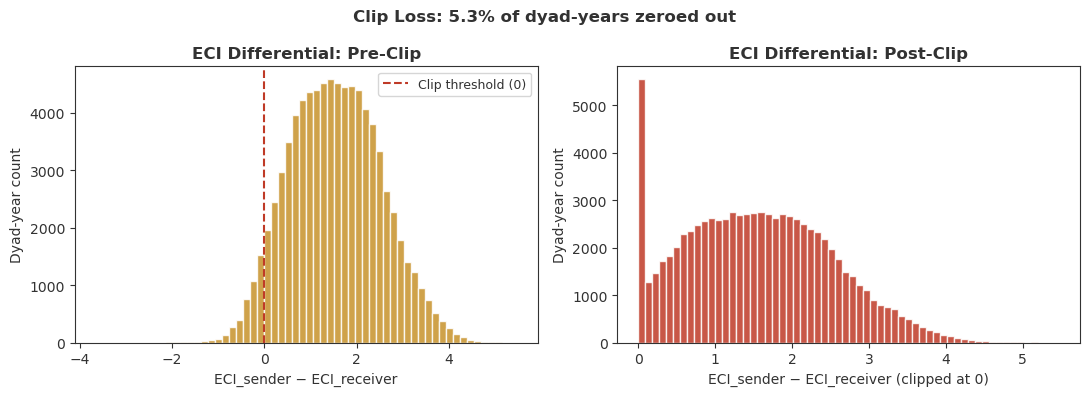

Saved.


In [10]:
# Visualise pre-clip vs post-clip differential distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(dyadic_eci['eci_diff_raw'].dropna(), bins=60, color=GOLD, edgecolor='white', alpha=0.85)
axes[0].axvline(0, color=RED, linestyle='--', linewidth=1.5, label='Clip threshold (0)')
axes[0].set_title('ECI Differential: Pre-Clip', fontweight='bold')
axes[0].set_xlabel('ECI_sender − ECI_receiver')
axes[0].set_ylabel('Dyad-year count')
axes[0].legend(fontsize=9)

axes[1].hist(dyadic_eci['eci_diff_clipped'].dropna(), bins=60, color=RED, edgecolor='white', alpha=0.85)
axes[1].set_title('ECI Differential: Post-Clip', fontweight='bold')
axes[1].set_xlabel('ECI_sender − ECI_receiver (clipped at 0)')
axes[1].set_ylabel('Dyad-year count')

fig.suptitle(f'Clip Loss: {pct_zeroed:.1f}% of dyad-years zeroed out', fontsize=12, fontweight='bold', color=DARK)
plt.tight_layout()
plt.savefig('../outputs/final_report/04_appendix/fig_audit_eci_clip_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## Section 3 — Within-Global South Variance After Clipping

Even among retained dyads, do the scores spread meaningfully or cluster near zero?

In [11]:
# Define Global South senders as those with ECI below median in their year
eci_medians = eci.groupby('year')['eci_hs92'].median().rename('eci_median_yr')
eci_with_med = eci.merge(eci_medians, on='year')
eci_with_med['is_gs'] = eci_with_med['eci_hs92'] < eci_with_med['eci_median_yr']
gs_isos = set(eci_with_med.loc[eci_with_med['is_gs'], 'iso3'].unique())

gs_dyads = dyadic_eci[dyadic_eci[SENDER_COL].isin(gs_isos)].copy()
gs_retained = gs_dyads[gs_dyads['eci_diff_clipped'] > 0]

print(f'Global South sender dyad-years: {len(gs_dyads):,}')
print(f'Retained after clip: {len(gs_retained):,} ({len(gs_retained)/len(gs_dyads)*100:.1f}%)')
print()
print('Post-clip differential stats (GS senders only):')
print(gs_retained['eci_diff_clipped'].describe())

Global South sender dyad-years: 3,452
Retained after clip: 1,873 (54.3%)

Post-clip differential stats (GS senders only):
count    1873.000000
mean        1.018809
std         0.663798
min         0.001000
25%         0.494000
50%         0.959000
75%         1.428000
max         3.844000
Name: eci_diff_clipped, dtype: float64


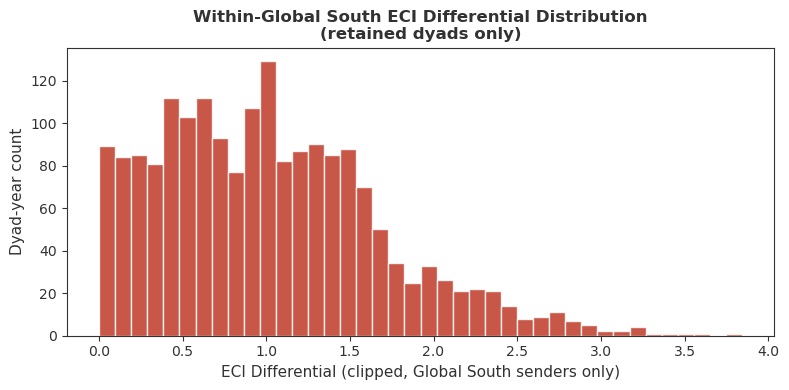

Saved.


In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(gs_retained['eci_diff_clipped'], bins=40, color=RED, edgecolor='white', alpha=0.85)
ax.set_xlabel('ECI Differential (clipped, Global South senders only)', fontsize=11)
ax.set_ylabel('Dyad-year count', fontsize=11)
ax.set_title('Within-Global South ECI Differential Distribution\n(retained dyads only)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/final_report/04_appendix/fig_audit_eci_gs_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## Section 4 — Monadic Score Variance Over Time

This reproduces the trajectory issue visible in nb18 fig — checking whether the flat post-1995 lines are a data artifact.

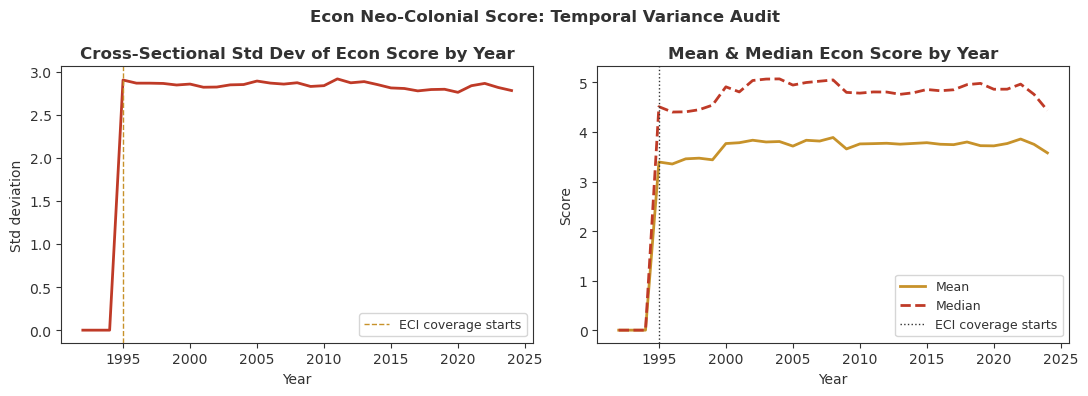

Saved.


In [13]:
# Cross-sectional variance of econ_neocol_score_total by year
score_var = (
    panel.groupby('year')['econ_neocol_score_total']
    .agg(['std', 'mean', 'median', 'count'])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(score_var['year'], score_var['std'], color=RED, linewidth=2)
axes[0].set_title('Cross-Sectional Std Dev of Econ Score by Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Std deviation')
axes[0].axvline(1995, color=GOLD, linestyle='--', linewidth=1, label='ECI coverage starts')
axes[0].legend(fontsize=9)

axes[1].plot(score_var['year'], score_var['mean'], color=GOLD, linewidth=2, label='Mean')
axes[1].plot(score_var['year'], score_var['median'], color=RED, linewidth=2, linestyle='--', label='Median')
axes[1].set_title('Mean & Median Econ Score by Year', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Score')
axes[1].axvline(1995, color=DARK, linestyle=':', linewidth=1, label='ECI coverage starts')
axes[1].legend(fontsize=9)

fig.suptitle('Econ Neo-Colonial Score: Temporal Variance Audit', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/final_report/04_appendix/fig_audit_econ_score_temporal_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## Section 5 — Score vs Journalist Killings: Global South Only

Re-runs the bivariate scatter from nb18 but restricted to Global South recipients to check whether the null is driven by Global North noise.

Global South recipient-years: 2,878
With non-zero econ score: 2,559


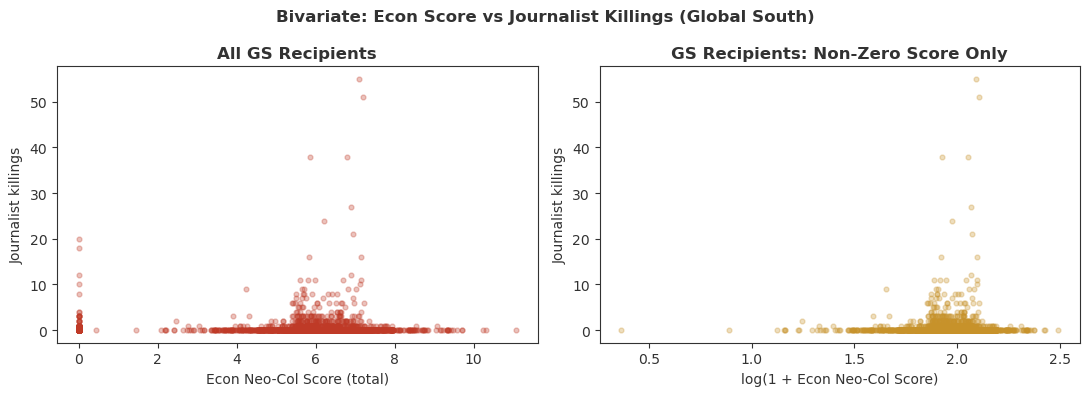

Saved.


In [14]:
# Restrict panel to GS recipients
panel_gs = panel[panel['recipient_iso3'].isin(gs_isos)].copy()
panel_gs_nonzero = panel_gs[panel_gs['econ_neocol_score_total'] > 0]

print(f'Global South recipient-years: {len(panel_gs):,}')
print(f'With non-zero econ score: {len(panel_gs_nonzero):,}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# All GS
axes[0].scatter(
    panel_gs['econ_neocol_score_total'],
    panel_gs['journalist_killings'],
    alpha=0.3, s=12, color=RED
)
axes[0].set_xlabel('Econ Neo-Col Score (total)')
axes[0].set_ylabel('Journalist killings')
axes[0].set_title('All GS Recipients', fontweight='bold')

# Non-zero score only (log scale)
axes[1].scatter(
    np.log1p(panel_gs_nonzero['econ_neocol_score_total']),
    panel_gs_nonzero['journalist_killings'],
    alpha=0.3, s=12, color=GOLD
)
axes[1].set_xlabel('log(1 + Econ Neo-Col Score)')
axes[1].set_ylabel('Journalist killings')
axes[1].set_title('GS Recipients: Non-Zero Score Only', fontweight='bold')

fig.suptitle('Bivariate: Econ Score vs Journalist Killings (Global South)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/final_report/04_appendix/fig_audit_econ_score_bivariate_gs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## Section 6 — Summary: Measurement Failure Audit

In [15]:
# Summary statistics for audit write-up
print('=== ECON NEO-COLONIAL SCORE VARIANCE AUDIT SUMMARY ===')
print()
print('1. Clip loss:')
print(f'   {pct_zeroed:.1f}% of dyad-years zeroed by clip(0)')
print()
print('2. Within-GS retained differential:')
print(f'   Mean:   {gs_retained["eci_diff_clipped"].mean():.3f}')
print(f'   Std:    {gs_retained["eci_diff_clipped"].std():.3f}')
print(f'   CV:     {gs_retained["eci_diff_clipped"].std() / gs_retained["eci_diff_clipped"].mean():.3f}')
print()
print('3. Monadic score variance post-1995:')
post95 = panel[panel['year'] >= 1995]
print(f'   Std of econ_neocol_score_total: {post95["econ_neocol_score_total"].std():.4f}')
print(f'   % of country-years with score = 0: {(post95["econ_neocol_score_total"]==0).mean()*100:.1f}%')
print()
print('4. Interpretation flag:')
cv = gs_retained['eci_diff_clipped'].std() / gs_retained['eci_diff_clipped'].mean()
if cv < 0.5:
    print('   LOW VARIANCE — null result likely reflects measurement failure, not genuine absence of structural effect')
else:
    print('   SUFFICIENT VARIANCE — null result is interpretable as genuine')

=== ECON NEO-COLONIAL SCORE VARIANCE AUDIT SUMMARY ===

1. Clip loss:
   5.3% of dyad-years zeroed by clip(0)

2. Within-GS retained differential:
   Mean:   1.019
   Std:    0.664
   CV:     0.652

3. Monadic score variance post-1995:
   Std of econ_neocol_score_total: 2.8387
   % of country-years with score = 0: 32.0%

4. Interpretation flag:
   SUFFICIENT VARIANCE — null result is interpretable as genuine
